# Road Scene Segmentation using U-Net

## Objective
The goal of this project is to perform semantic segmentation of road scenes, classifying each pixel in an image into different categories. This type of work is critical in computer vision applications like autonomous driving.

## Dataset
- **Name:** CamVid(Cambridge-driving Labeled Video Database)
- **Source:** [Kaggle CamVid Dataset](https://www.kaggle.com/datasets/carlolepelaars/camvid)
- **Total Number of Classes:** 32 semantic classes

## Tools & Technologies
- Python, Numpy, Pandas
- TensorFlow/Keras (deep learning framework)
- segmentation_models (U-Net with ResNet backbone)
- OpenCV (image loading & pre-processing)
- Albumentations (image augmentation)
- Matplotlib (visualization)
- Scikit-learn (model evaluation)

## Workflow
1. **Data Preparation**
   - Load images & masks
   - Convert RGB masks to class index masks
   - Data augmentation (resize, flips, brightness, noise, etc.)
2. **Custom Data Generator**
   - Efficient loading of images and masks
   - Augmentation
   - One-hot encoding of masks
3. **Model**
   - U-Net with ResNet50 backbone (pretrained on ImageNet)
   - Loss: Categorical CrossEntropy + Focal Loss
   - Metrics: IoU (Intersection over Union), F1 Score
4. **Training & Evaluation**
   - Model checkpointing, early stopping, learning rate scheduling
   - Visualization of training curve
   - Evaluation on test set
5. **Results & Visualization**
   - Training/Validation loss, IoU, F1 Score
   - Visualization of Input Image vs Ground Truth vs Prediction

## Results
- **IoU Score:** 0.6211
- **F1 Score:** 0.6562
- **Test Loss:** 0.0180
- Model saved as 'unet_resnet50.keras'.

### Import Libraries

In [1]:
# Import required libraries
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import tensorflow as tf
import random

import segmentation_models as sm

from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

Segmentation Models: using `tf.keras` framework.


In [2]:
# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

### Parameters and Dataset Setup

In [3]:
# Set data path and parameters
main_dir = "CamVid"
batch_size = 2
epochs = 50
img_size = (256,256)
backbone = "resnet50"

In [4]:
# Load class dictionary
class_dict = pd.read_csv(os.path.join(main_dir, "class_dict.csv"))

# Create color map
color_to_index = {(row.r, row.g, row.b): i for i, row in class_dict.iterrows()}    # RGB -> class index
index_to_color = {i: (row.r, row.g, row.b) for i, row in class_dict.iterrows()}    # class index -> RGB

class_names = class_dict['name'].tolist()
num_classes = len(index_to_color)
print("Number of Classes:", num_classes)

Number of Classes: 32


### Mask conversion

In [5]:
def color_to_class(mask):
    """
    Convert RGB segmentation mask to integer class mask.
    Each unique RGB color corresponds to one class index.
    """
    h, w, c = mask.shape
    mask_out = np.zeros((h,w), dtype=np.int64)

    for color, idx in color_to_index.items():
        r, g, b = color
        match = (mask[:, :, 0] == r) & (mask[:, :, 1] == g) & (mask[:, :, 2] == b)
        mask_out[match] = idx

    return mask_out

### Data Augmentation (Albumentations)

In [6]:
# Data augmentation on train, val and test data
train_aug = A.Compose([
    A.Resize(*img_size),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.GaussNoise(p=0.2)
])

val_aug = A.Compose([A.Resize(*img_size)])
test_aug = A.Compose([A.Resize(*img_size)])

### Data Generator class

In [7]:
class SegmentationDataGenerator(Sequence):
    """
    Custom data generator for semantic segmentation.
    Loads images & masks, applies augmentation, and outputs image batches with one-hot encoded masks.
    """
    def __init__(self, image_dir, mask_dir, color_to_class, batch_size=2, img_size=(256,256), augment=None, shuffle=True, backbone=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.color_to_class = color_to_class
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle

        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.indices = np.arange(len(self.image_files))

        # Preprocessing input data from segmentation_models
        self.preprocess_input = sm.get_preprocessing(backbone) if backbone else None

    def __len__(self):
        """
        Return total number of batches per epoch
        """
        return int(np.ceil(len(self.image_files) / self.batch_size))

    def on_epoch_end(self):
        """
        Shuffle dataset indices after each epoch
        """
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        """
        Generate one batch of images and masks.
        """
        start = idx * self.batch_size
        end = (idx + 1) * self.batch_size
        batch_indices = self.indices[start:end]

        images = []
        masks = []
        
        for i in batch_indices:
            # Load image
            img_path = os.path.join(self.image_dir, self.image_files[i])
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Load mask
            mask_path = os.path.join(self.mask_dir, self.mask_files[i])
            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            mask = self.color_to_class(mask)  # Convert RGB → class index

            # Apply augmentation (if available)
            if self.augment is not None:
                data = self.augment(image=img, mask=mask)
                img, mask = data["image"], data["mask"]
            else:
                img = cv2.resize(img, self.img_size)
                mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

            images.append(img)
            masks.append(mask)

        # Convert to NumPy arrays
        images = np.array(images, dtype=np.float32)
        if self.preprocess_input:
            images = self.preprocess_input(images)

        # One-hot encode masks
        masks = np.expand_dims(np.array(masks, dtype=np.int64), axis=-1)
        masks = to_categorical(masks, num_classes=num_classes).astype("float32")

        return images, masks

### Preprocess data

In [8]:
# Paths for Train/Val/Test data
train_images = os.path.join(main_dir, "train")
train_masks = os.path.join(main_dir, "train_labels")
val_images = os.path.join(main_dir, "val")
val_masks = os.path.join(main_dir, "val_labels")
test_images = os.path.join(main_dir, "test")
test_masks = os.path.join(main_dir, "test_labels")

In [9]:
# Create Data Generators
train_gen = SegmentationDataGenerator(train_images, train_masks, color_to_class, batch_size=batch_size, img_size=img_size, augment=train_aug, backbone=backbone)
val_gen = SegmentationDataGenerator(val_images, val_masks, color_to_class, batch_size=batch_size, img_size=img_size, augment=val_aug, backbone=backbone)
test_gen = SegmentationDataGenerator(test_images, test_masks, color_to_class, batch_size=batch_size, img_size=img_size, augment=test_aug, backbone=backbone, shuffle=False)

### Model setup: U-Net with ResNet50 as backbone

In [10]:
# Build UNet model with pretrained backbone
model = sm.Unet(
    backbone_name=backbone, 
    input_shape=(img_size[0], img_size[1], 3), 
    encoder_weights="imagenet", 
    classes=num_classes, 
    activation="softmax"
)

94592056/94592056 [==============================] - 18s 0us/step


In [11]:
# Compile model
optimizer = Adam(learning_rate=1e-4)
loss = (
    sm.losses.CategoricalCELoss() + 
    sm.losses.CategoricalFocalLoss()
)
metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 bn_data (BatchNormalization)   (None, 256, 256, 3)  9           ['data[0][0]']                   
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 262, 262, 3)  0          ['bn_data[0][0]']                
                                                                                                  
 conv0 (Conv2D)                 (None, 128, 128, 64  9408        ['zero_padding2d[0][0]']   

### Setup Callbacks and Train the model

In [12]:
# Set callbacks
checkpoint = ModelCheckpoint("unet_resnet50.weights.h5", monitor="val_iou_score", save_best_only=True, save_weights_only=True, mode="max")
lr_reducer = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

callbacks = [checkpoint, lr_reducer, early_stop]

In [13]:
# Train the model
history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks, verbose=1)

Epoch 1/50
185/185 [==============================] - 399s 2s/step - loss: 0.0902 - iou_score: 0.4378 - f1-score: 0.4392 - val_loss: 0.0614 - val_iou_score: 0.4736 - val_f1-score: 0.4811 - lr: 1.0000e-04
Epoch 2/50
185/185 [==============================] - 387s 2s/step - loss: 0.0495 - iou_score: 0.4294 - f1-score: 0.4487 - val_loss: 0.0409 - val_iou_score: 0.4616 - val_f1-score: 0.4824 - lr: 1.0000e-04
Epoch 3/50
185/185 [==============================] - 388s 2s/step - loss: 0.0379 - iou_score: 0.4743 - f1-score: 0.4985 - val_loss: 0.0336 - val_iou_score: 0.4829 - val_f1-score: 0.5028 - lr: 1.0000e-04
Epoch 4/50
185/185 [==============================] - 388s 2s/step - loss: 0.0332 - iou_score: 0.4928 - f1-score: 0.5158 - val_loss: 0.0293 - val_iou_score: 0.4898 - val_f1-score: 0.5086 - lr: 1.0000e-04
Epoch 5/50
185/185 [==============================] - 390s 2s/step - loss: 0.0296 - iou_score: 0.4981 - f1-score: 0.5201 - val_loss: 0.0281 - val_iou_score: 0.4924 - val_f1-score: 0.51

### Plot Training Curves

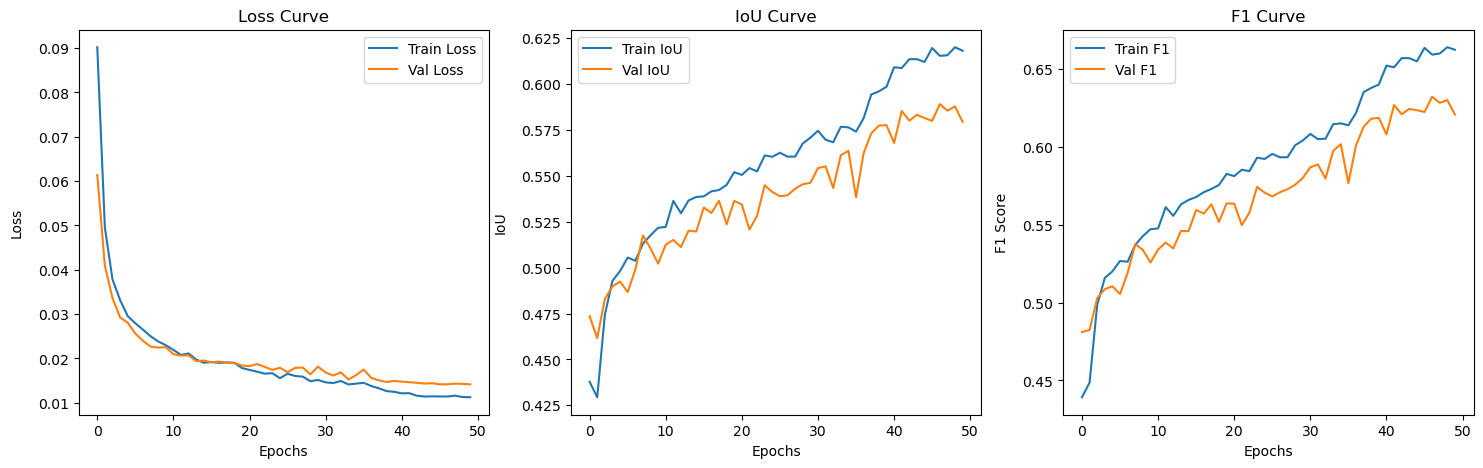

In [14]:
def plot_training_curves(history, save_dir="assets", filename="training_curves.png"):
    """
    Plot loss, IoU, and F1-score curves and save them as PNG.
    """
    # Ensure directory exists
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)
    
    plt.figure(figsize=(18,5))

    # Loss curve
    plt.subplot(1,3,1)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.xlabel('Epochs')
    plt.ylabel('Loss', labelpad=10)
    plt.legend()
    plt.title('Loss Curve')

    # IoU curve
    if 'iou_score' in history.history:
        plt.subplot(1, 3, 2)
        plt.plot(history.history['iou_score'], label='Train IoU')
        plt.plot(history.history['val_iou_score'], label='Val IoU')
        plt.xlabel('Epochs')
        plt.ylabel('IoU', labelpad=10)
        plt.legend()
        plt.title('IoU Curve')

    # F1-score curve
    if 'f1-score' in history.history or 'fscore' in history.history:
        f1_key = 'f1-score' if 'f1-score' in history.history else 'fscore'
        plt.subplot(1, 3, 3)
        plt.plot(history.history[f1_key], label='Train F1')
        plt.plot(history.history['val_' + f1_key], label='Val F1')
        plt.xlabel('Epochs')
        plt.ylabel('F1 Score', labelpad=10)
        plt.legend()
        plt.title('F1 Curve')
    
    # Save figure
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_training_curves(history)

### Model Evaluation

In [15]:
# Load best weights
model.load_weights("unet_resnet50.weights.h5")

# Evaluate with best weights
test_scores = model.evaluate(test_gen, verbose=1)
print(f"Test Loss: {test_scores[0]:.4f}")
print(f"Test IoU: {test_scores[1]:.4f}")
print(f"Test F1 Score: {test_scores[2]:.4f}")

116/116 [==============================] - 58s 499ms/step - loss: 0.0180 - iou_score: 0.6211 - f1-score: 0.6562
Test Loss: 0.0180
Test IoU: 0.6211
Test F1 Score: 0.6562


In [16]:
# Save full model architecture, weights and optimizer
model.save("unet_resnet50.keras")
print("Full model saved!")

Full model saved!


### Visualization of Predictions

1/1 [==============================] - 0s 166ms/step


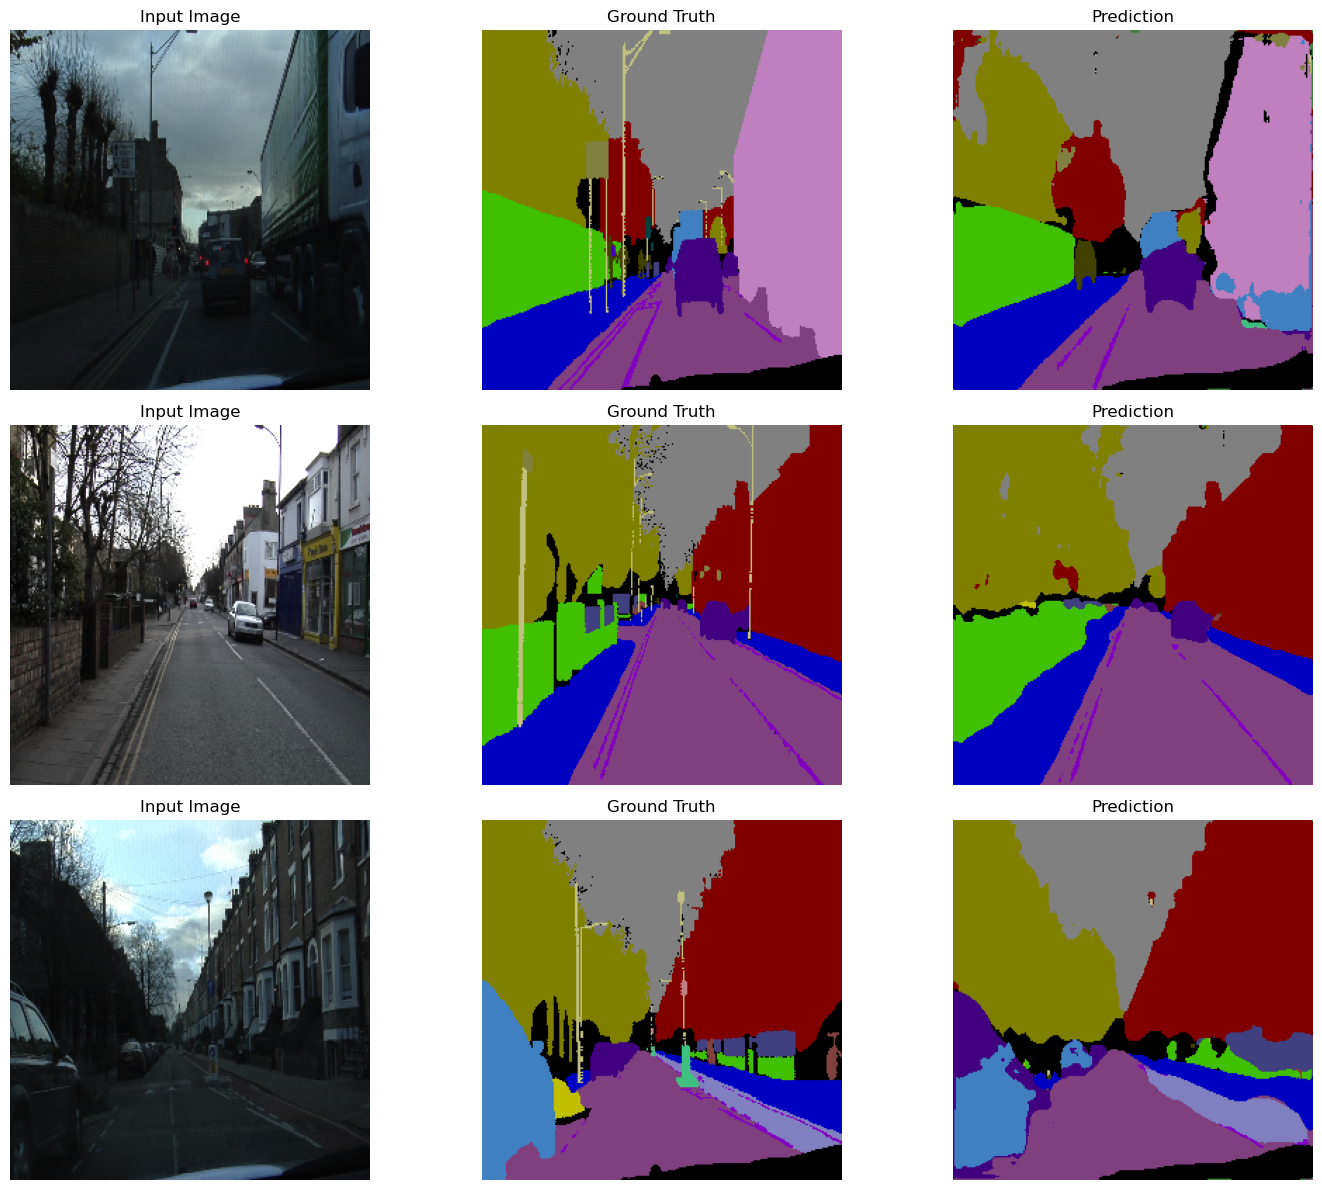

In [17]:
def decode_mask(mask, index_to_color):
    """
    Convert class index mask to RGB mask
    """
    h, w = mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, color in index_to_color.items():
        rgb_mask[mask == idx] = color
    return rgb_mask

def visualize_random_samples(model, generator, index_to_color, num_samples=3, save_dir="assets", filename="predictions.png"):
    """
    Visualize and save random test samples:
    - Input image
    - Ground truth
    - Model prediction
    """
    # Ensure directory exists
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)
    
    indices = random.sample(range(len(generator.image_files)), num_samples)
    plt.figure(figsize=(15, num_samples * 4))

    for i, idx in enumerate(indices):
        # Load image + ground truth
        img_path = os.path.join(generator.image_dir, generator.image_files[idx])
        mask_path = os.path.join(generator.mask_dir, generator.mask_files[idx])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = generator.color_to_class(mask)

        # Resize for consistency
        img_resized = cv2.resize(img, generator.img_size)
        mask_resized = cv2.resize(mask, generator.img_size, interpolation=cv2.INTER_NEAREST)

        # Predict
        img_input = np.expand_dims(img_resized, axis=0).astype("float32")
        if generator.preprocess_input:
            img_input = generator.preprocess_input(img_input)

        pred = model.predict(img_input)
        pred_label = np.argmax(pred[0], axis=-1)

        # Show input
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img_resized.astype(np.uint8))
        plt.title("Input Image")
        plt.axis("off")

        # Show ground truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(decode_mask(mask_resized, index_to_color))
        plt.title("Ground Truth")
        plt.axis("off")

        # Show prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(decode_mask(pred_label, index_to_color))
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

visualize_random_samples(model, test_gen, index_to_color, num_samples=3)